In [ ]:
# NOTE: Install needed packages and import the main libraries used in the notebook.
# Install KaggleHub and import required libraries
!pip install -q kagglehub

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import kagglehub

In [ ]:
# NOTE: Download the RAF-DB dataset and define the main train/test folder paths.
# Download RAF-DB dataset from Kaggle
DATASET_PATH = kagglehub.dataset_download("shuvoalok/raf-db-dataset")

# Define train and test directories
DATA_DIR = os.path.join(DATASET_PATH, "DATASET")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Dataset downloaded to:", DATASET_PATH)
print("Train folder:", TRAIN_DIR)
print("Test folder:", TEST_DIR)

Using Colab cache for faster access to the 'raf-db-dataset' dataset.
Dataset downloaded to: /kaggle/input/raf-db-dataset
Train folder: /kaggle/input/raf-db-dataset/DATASET/train
Test folder: /kaggle/input/raf-db-dataset/DATASET/test


In [ ]:
# NOTE: Set the main configuration values and prepare basic image preprocessing.
# Define configuration values
IMAGE_SIZE = 112
BATCH_SIZE = 64
VAL_RATIO = 0.10
SEED = 42

# Define preprocessing transforms for RGB images
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# RAF-DB original folder label mapping
RAF_LABEL_MAP = {
    "1": "Surprise",
    "2": "Fear",
    "3": "Disgust",
    "4": "Happy",
    "5": "Sad",
    "6": "Angry",
    "7": "Neutral"
}

train_full_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=base_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=base_transform
)

CLASS_NAMES = [RAF_LABEL_MAP[class_id] for class_id in train_full_dataset.classes]
NUM_CLASSES = len(CLASS_NAMES)

print("Original folder labels:", train_full_dataset.classes)
print("Emotion class names:", CLASS_NAMES)
print("Class to index:", train_full_dataset.class_to_idx)
print("Number of classes:", NUM_CLASSES)
print("Train images:", len(train_full_dataset))
print("Test images:", len(test_dataset))

Original folder labels: ['1', '2', '3', '4', '5', '6', '7']
Emotion class names: ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
Class to index: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}
Number of classes: 7
Train images: 12271
Test images: 3068


In [ ]:
# NOTE: Split the original training data into training and validation datasets.
# Split training data into train and validation sets
val_size = int(len(train_full_dataset) * VAL_RATIO)
train_size = len(train_full_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=generator
)

# Store all datasets in one dictionary
datasets_dict = {
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
}

# Create DataLoaders for batch processing
dataloaders = {
    "train": DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True),
    "val": DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False),
    "test": DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
}

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))
print("DataLoaders created successfully.")

Train size: 11044
Validation size: 1227
Test size: 3068
DataLoaders created successfully.


# **(ResNet18)**

In [ ]:
# NOTE: Prepare a pretrained ResNet18 model and modify it for emotion classification.
import torch
import torch.nn as nn
from torchvision import models

# Use same device as your main model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# LOAD PRETRAINED RESNET18
resnet_model = models.resnet18(pretrained=True)

# Freeze feature extractor (IMPORTANT for transfer learning)
for param in resnet_model.parameters():
    param.requires_grad = False



# Replace last layer for RAF-DB (7 classes)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 7)

resnet_model = resnet_model.to(device)

print("ResNet18 loaded successfully")

ResNet18 loaded successfully


In [ ]:
# NOTE: Set the loss function, optimizer, and training loop for the ResNet18 model.
# LOSS & OPTIMIZER

criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)



# SCHEDULER
scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode="min",
    factor=0.5,
    patience=3
)

# TRAINING SETTINGS

epochs_resnet = 50

train_acc_resnet = []
val_acc_resnet = []

train_loss_resnet = []
val_loss_resnet = []

for epoch in range(epochs_resnet):

    #  TRAIN
    resnet_model.train()

    correct = 0
    total = 0
    running_loss = 0

    for images, labels in dataloaders["train"]:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_resnet.zero_grad()

        outputs = resnet_model(images)
        loss = criterion_resnet(outputs, labels)

        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(dataloaders["train"])
    train_acc = 100 * correct / total

    train_loss_resnet.append(train_loss)
    train_acc_resnet.append(train_acc)

    #  VALIDATION
    resnet_model.eval()

    correct = 0
    total = 0
    val_running_loss = 0

    with torch.no_grad():
        for images, labels in dataloaders["val"]:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model(images)
            loss = criterion_resnet(outputs, labels)

            val_running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = val_running_loss / len(dataloaders["val"])
    val_acc = 100 * correct / total

    val_loss_resnet.append(val_loss)
    val_acc_resnet.append(val_acc)

    # STEP SCHEDULER (IMPORTANT)
    scheduler_resnet.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs_resnet}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/50] Train Loss: 1.1657 | Train Acc: 56.24% | Val Loss: 1.2711 | Val Acc: 52.89%
Epoch [2/50] Train Loss: 1.1537 | Train Acc: 57.28% | Val Loss: 1.2683 | Val Acc: 53.71%
Epoch [3/50] Train Loss: 1.1575 | Train Acc: 57.01% | Val Loss: 1.2672 | Val Acc: 53.55%
Epoch [4/50] Train Loss: 1.1571 | Train Acc: 56.84% | Val Loss: 1.2687 | Val Acc: 53.63%
Epoch [5/50] Train Loss: 1.1556 | Train Acc: 57.13% | Val Loss: 1.2708 | Val Acc: 53.46%
Epoch [6/50] Train Loss: 1.1531 | Train Acc: 57.38% | Val Loss: 1.2698 | Val Acc: 53.30%
Epoch [7/50] Train Loss: 1.1522 | Train Acc: 57.03% | Val Loss: 1.2731 | Val Acc: 53.38%
Epoch [8/50] Train Loss: 1.1494 | Train Acc: 57.24% | Val Loss: 1.2671 | Val Acc: 53.79%
Epoch [9/50] Train Loss: 1.1477 | Train Acc: 57.31% | Val Loss: 1.2689 | Val Acc: 53.63%
Epoch [10/50] Train Loss: 1.1474 | Train Acc: 57.14% | Val Loss: 1.2682 | Val Acc: 53.95%
Epoch [11/50] Train Loss: 1.1492 | Train Acc: 57.15% | Val Loss: 1.2662 | Val Acc: 53.38%
Epoch [12/50] Train

In [ ]:
# NOTE: Save the trained ResNet18 model and evaluate it on the test set.
# SAVE MODEL
torch.save(resnet_model.state_dict(), "resnet18_rafdb.pth")
print("ResNet18 model saved successfully")


# TEST EVALUATION (SAME TEST SET)

resnet_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in dataloaders["test"]:  # SAME TEST SET
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

resnet_test_acc = 100 * correct / total

print(f"ResNet18 Test Accuracy: {resnet_test_acc:.2f}%")

ResNet18 model saved successfully
ResNet18 Test Accuracy: 53.10%


In [ ]:
# NOTE: Count how many images exist in each class for train, validation, and test splits.
# Count labels for each split and display class distribution
def get_label_counts(dataset, class_names):
    counts = {class_name: 0 for class_name in class_names}

    for _, label in dataset:
        counts[class_names[label]] += 1

    return counts


rows = []

for split_name, dataset in datasets_dict.items():
    counts = get_label_counts(dataset, CLASS_NAMES)
    row = {"Split": split_name, "Total": len(dataset)}
    row.update(counts)
    rows.append(row)

stats_df = pd.DataFrame(rows)
display(stats_df)

,Split,Total,Surprise,Fear,Disgust,Happy,Sad,Angry,Neutral
0,train,11044,1155,256,633,4306,1791,644,2259
1,val,1227,135,25,84,466,191,61,265
2,test,3068,329,74,160,1185,478,162,680


In [ ]:
# NOTE: Check one training batch to confirm that images and labels load correctly.
# Inspect one batch to make sure the DataLoader works correctly
images, labels = next(iter(dataloaders["train"]))

example_label_ids = labels[:10].tolist()
example_label_names = [CLASS_NAMES[label] for label in example_label_ids]

batch_info = pd.DataFrame({
    "Item": [
        "Images shape",
        "Labels shape",
        "Image dtype",
        "Label dtype",
        "Min image value",
        "Max image value",
        "Example label ids",
        "Example label names"
    ],
    "Value": [
        str(tuple(images.shape)),
        str(tuple(labels.shape)),
        str(images.dtype),
        str(labels.dtype),
        images.min().item(),
        images.max().item(),
        example_label_ids,
        example_label_names
    ]
})

display(batch_info)

print("Pipeline is ready for training.")
print("Input shape for CNN:", images.shape)
print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

,Item,Value
0,Images shape,"(64, 3, 112, 112)"
1,Labels shape,"(64,)"
2,Image dtype,torch.float32
3,Label dtype,torch.int64
4,Min image value,-1.0
5,Max image value,1.0
6,Example label ids,"[2, 4, 3, 5, 6, 3, 6, 3, 3, 5]"
7,Example label names,"[Disgust, Sad, Happy, Angry, Neutral, Happy, N..."


Pipeline is ready for training.
Input shape for CNN: torch.Size([64, 3, 112, 112])
Number of classes: 7
Class names: ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']


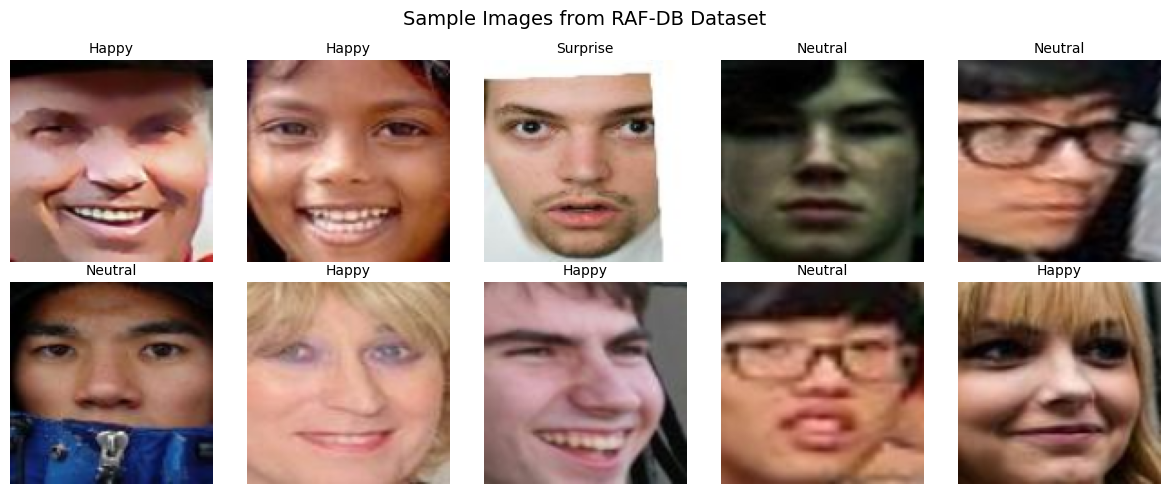

In [ ]:
# NOTE: Display random training images to visually inspect the dataset.
# Show random sample images from the training set
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Images from RAF-DB Dataset", fontsize=14)

indices = torch.randint(len(train_dataset), (10,))

for i, idx in enumerate(indices):
    image, label = train_dataset[idx]

    # Denormalize image from [-1, 1] to [0, 1]
    image = image * 0.5 + 0.5

    # Convert from CHW to HWC for matplotlib
    image = image.permute(1, 2, 0)

    emotion_name = CLASS_NAMES[int(label)]

    axes[i // 5, i % 5].imshow(image)
    axes[i // 5, i % 5].set_title(emotion_name, fontsize=10)
    axes[i // 5, i % 5].axis("off")

plt.tight_layout()
plt.show()

# **Preprocessing + Augmentation**

In [ ]:
# NOTE: Define augmentation for training images and clean preprocessing for validation/test images.
# Train preprocessing with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
     # Apply small random affine transformations
    # Includes slight translations (shift up/down/left/right by 5%)
    # Helps the model handle object position variations
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    # Randomly adjust image brightness and contrast
    # Simulates different lighting conditions in real-world data
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# Validation / Test preprocessing without augmentation
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("Preprocessing transforms created.")

Preprocessing transforms created.


In [ ]:
# NOTE: Reload datasets with transforms, create train/validation splits, and build DataLoaders.
# 1. Load the full datasets with their respective transforms
train_full_augmented = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
train_full_clean = datasets.ImageFolder(root=TRAIN_DIR, transform=test_transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transform)

# 2. Generate indices for train and validation splits manually using SEED
num_train_examples = len(train_full_augmented)
val_size = int(num_train_examples * VAL_RATIO)
train_size = num_train_examples - val_size

# Fix seed for reproducibility
np.random.seed(SEED)
indices = np.random.permutation(num_train_examples)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

# 3. Create Subsets safely using the correct text/augmented targets
train_dataset = torch.utils.data.Subset(train_full_augmented, train_indices)
val_dataset = torch.utils.data.Subset(train_full_clean, val_indices)

# 4. Store in dictionary for Person 5 (Evaluation) to use later
datasets_dict = {
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
}

# 5. Create DataLoaders for batch processing (Person 1)
dataloaders = {
    "train": DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True),
    "val": DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False),
    "test": DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
}

print("Pipeline linked successfully!")
print(f"Train size (Augmented): {len(train_dataset)}")
print(f"Validation size (Clean): {len(val_dataset)}")
print(f"Test size (Clean): {len(test_dataset)}")

Pipeline linked successfully!
Train size (Augmented): 11044
Validation size (Clean): 1227
Test size (Clean): 3068


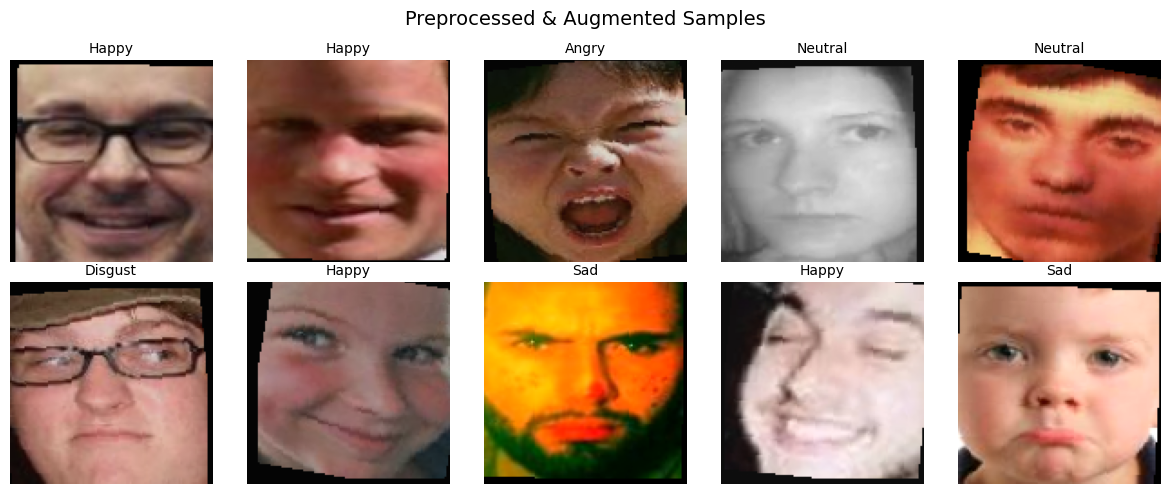

In [ ]:
# NOTE: Show examples after preprocessing and augmentation to verify the transformations.
# Show preprocessed and augmented samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Preprocessed & Augmented Samples", fontsize=14)

indices = torch.randperm(len(train_dataset))[:10]

for i, idx in enumerate(indices):
    image, label = train_dataset[idx]

    # Denormalize
    image = image * 0.5 + 0.5
    image = torch.clamp(image, 0, 1)

    # RGB format: (C, H, W) → (H, W, C)
    image = image.permute(1, 2, 0)

    emotion_name = CLASS_NAMES[int(label)]

    axes[i // 5, i % 5].imshow(image)
    axes[i // 5, i % 5].set_title(emotion_name, fontsize=10)
    axes[i // 5, i % 5].axis("off")

plt.tight_layout()
plt.show()

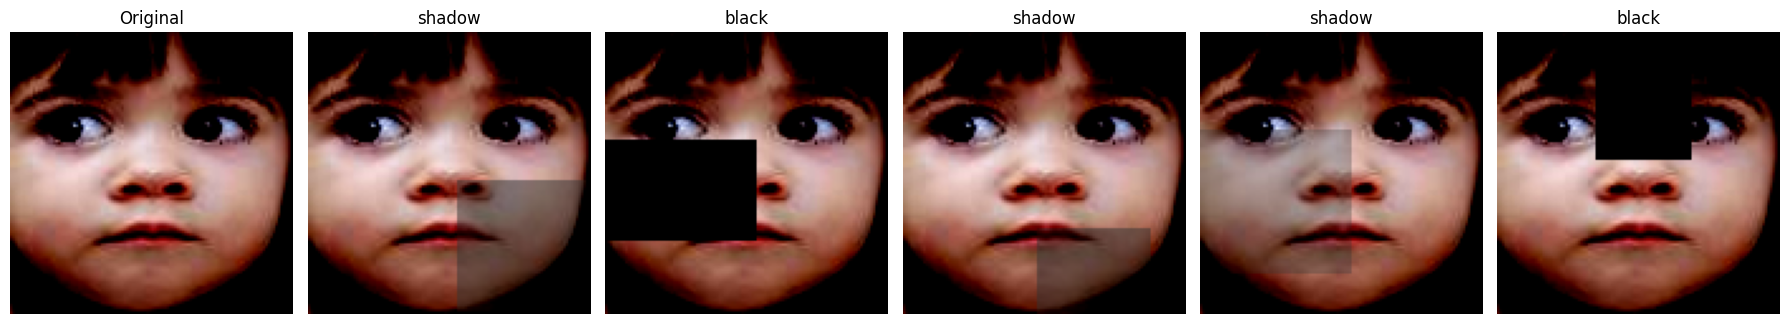

In [ ]:
# NOTE: Define occlusion functions that hide part of an image to test model robustness.
import random
import numpy as np
import matplotlib.pyplot as plt
import torch


# SOFT SHADOW OCCLUSION

def shadow_occlusion(image, min_size=25, max_size=60):
    occluded = image.clone()
    mask = torch.ones_like(image)

    _, h, w = image.shape

    bw = random.randint(min_size, max_size)
    bh = random.randint(min_size, max_size)

    direction = random.choice(["top", "bottom", "left", "right"])
    alpha = random.uniform(0.3, 0.6)

    shadow_value = 0.2

    if direction == "top":
        x = random.randint(0, w - bw)
        y = 0
    elif direction == "bottom":
        x = random.randint(0, w - bw)
        y = h - bh
    elif direction == "left":
        x = 0
        y = random.randint(0, h - bh)
    else:
        x = w - bw
        y = random.randint(0, h - bh)

    patch = occluded[:, y:y+bh, x:x+bw]
    shadow = torch.full_like(patch, shadow_value)

    occluded[:, y:y+bh, x:x+bw] = (1 - alpha) * patch + alpha * shadow
    mask[:, y:y+bh, x:x+bw] = 0.0

    return occluded, mask



# HARD BLACK OCCLUSION

def black_occlusion(image, min_size=25, max_size=60):
    occluded = image.clone()
    mask = torch.ones_like(image)

    _, h, w = image.shape

    bw = random.randint(min_size, max_size)
    bh = random.randint(min_size, max_size)

    direction = random.choice(["top", "bottom", "left", "right"])

    if direction == "top":
        x = random.randint(0, w - bw)
        y = 0
    elif direction == "bottom":
        x = random.randint(0, w - bw)
        y = h - bh
    elif direction == "left":
        x = 0
        y = random.randint(0, h - bh)
    else:
        x = w - bw
        y = random.randint(0, h - bh)

    occluded[:, y:y+bh, x:x+bw] = 0.0
    mask[:, y:y+bh, x:x+bw] = 0.0

    return occluded, mask


# SAMPLE IMAGE

sample_image = dataset[0][0]


# CREATE MIXED SAMPLES

results = []

#  shadow samples
for _ in range(3):
    results.append(("shadow",) + shadow_occlusion(sample_image))

#  black samples
for _ in range(2):
    results.append(("black",) + black_occlusion(sample_image))


# shuffle
random.shuffle(results)



# VISUALIZE

plt.figure(figsize=(18, 4))

orig = sample_image.permute(1, 2, 0).squeeze().numpy()

plt.subplot(1, 6, 1)
plt.imshow(orig, cmap="gray")
plt.title("Original")
plt.axis("off")

for i, (typ, occ, mask) in enumerate(results):
    occ_img = occ.permute(1, 2, 0).squeeze().numpy()

    plt.subplot(1, 6, i + 2)
    plt.imshow(occ_img, cmap="gray")
    plt.title(typ)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# NOTE: Select GPU if available; otherwise use CPU.
import torch
import torch.nn as nn

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
# NOTE: Build the custom CNN architecture used for emotion classification.
# CNN model with Extra CNN Layer

class EmotionCNN(nn.Module):

    def __init__(self, num_classes=7):

        super(EmotionCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Extra CNN Layer
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [ ]:
# NOTE: Create the CNN model instance and move it to the selected device.
# Create model

model = EmotionCNN(num_classes=NUM_CLASSES).to(device)

print(model)

EmotionCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1

In [ ]:
# NOTE: Define the loss function and optimizer for the CNN model.
# Loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
# NOTE: Create a scheduler to reduce the learning rate when validation loss stops improving.
# Reduce learning rate if validation loss stops improving

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [ ]:
# NOTE: Set training parameters and lists used to store losses and accuracies.
# Training settings

EPOCHS = 50

early_stopping_patience = 7
best_val_loss = float("inf")
early_stopping_counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [ ]:
# NOTE: Train the CNN model, validate it each epoch, and apply early stopping.
# Training loop

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloaders["train"]:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(dataloaders["train"])

    train_acc = 100 * correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_acc)

    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in dataloaders["val"]:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(dataloaders["val"])

    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)

    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # Early Stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        early_stopping_counter = 0

        torch.save(model.state_dict(), "emotion_model_base.pth")

        print("Best base model saved.")

    else:

        early_stopping_counter += 1

        print(f"Early stopping counter: {early_stopping_counter}/{early_stopping_patience}")

        if early_stopping_counter >= early_stopping_patience:

            print("Early stopping triggered.")
            break

model.load_state_dict(torch.load("emotion_model_base.pth"))

print("Best base model loaded.")

Epoch [1/50] Train Loss: 2.2396 | Train Acc: 35.59% | Val Loss: 1.5535 | Val Acc: 40.75%
Best base model saved.
Epoch [2/50] Train Loss: 1.6389 | Train Acc: 39.26% | Val Loss: 1.5538 | Val Acc: 40.91%
Early stopping counter: 1/7
Epoch [3/50] Train Loss: 1.6196 | Train Acc: 39.22% | Val Loss: 1.4923 | Val Acc: 43.03%
Best base model saved.
Epoch [4/50] Train Loss: 1.5488 | Train Acc: 42.38% | Val Loss: 1.3190 | Val Acc: 51.02%
Best base model saved.
Epoch [5/50] Train Loss: 1.4332 | Train Acc: 46.79% | Val Loss: 1.3134 | Val Acc: 52.57%
Best base model saved.
Epoch [6/50] Train Loss: 1.3698 | Train Acc: 49.32% | Val Loss: 1.1870 | Val Acc: 58.19%
Best base model saved.
Epoch [7/50] Train Loss: 1.2913 | Train Acc: 53.12% | Val Loss: 1.1247 | Val Acc: 56.64%
Best base model saved.
Epoch [8/50] Train Loss: 1.2655 | Train Acc: 54.68% | Val Loss: 1.0732 | Val Acc: 60.47%
Best base model saved.
Epoch [9/50] Train Loss: 1.2189 | Train Acc: 55.86% | Val Loss: 1.0541 | Val Acc: 63.08%
Best base 

In [ ]:
# NOTE: Evaluate the trained CNN model on the test set.
# Test evaluation

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in dataloaders["test"]:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 81.55%


In [ ]:
# NOTE: Test the CNN model on occluded images to measure robustness.
# Test on occluded images

model.eval()

occluded_correct = 0
occluded_total = 0

with torch.no_grad():

    for images, labels in dataloaders["test"]:

        occluded_images = []

        for img in images:

            occluded_img, _ = black_occlusion(img)

            occluded_images.append(occluded_img)

        images = torch.stack(occluded_images)

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        occluded_total += labels.size(0)

        occluded_correct += (predicted == labels).sum().item()

occluded_accuracy = 100 * occluded_correct / occluded_total

print(f"Occluded Test Accuracy: {occluded_accuracy:.2f}%")

Occluded Test Accuracy: 73.79%


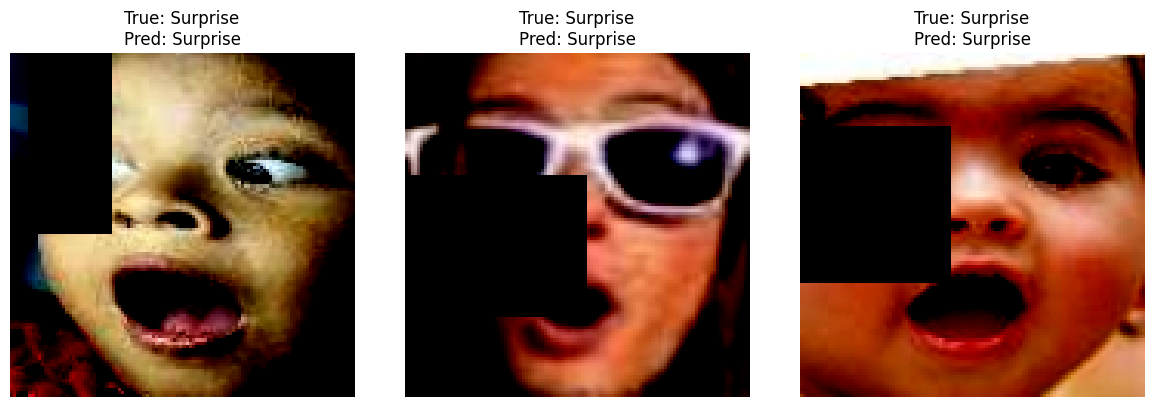

In [ ]:
# NOTE: Visualize a few occluded test images with their true and predicted labels.
import random
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(dataloaders["test"]))

random_indices = random.sample(range(len(images)), 3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

with torch.no_grad():

    for ax, idx in zip(axes, random_indices):

        img = images[idx]

        occluded_img, _ = black_occlusion(img)

        output = model(
            occluded_img.unsqueeze(0).to(device)
        )

        pred = torch.argmax(output, dim=1).item()

        ax.imshow(occluded_img.permute(1, 2, 0))

        ax.set_title(
            f"True: {CLASS_NAMES[labels[idx]]}\nPred: {CLASS_NAMES[pred]}"
        )

        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# NOTE: Create a dataset wrapper that applies occlusion before returning each image.
class OccludedDataset(torch.utils.data.Dataset):

    def __init__(self, base_dataset):

        self.base_dataset = base_dataset

    def __len__(self):

        return len(self.base_dataset)

    def __getitem__(self, idx):

        image, label = self.base_dataset[idx]

        image, _ = black_occlusion(image)

        return image, label


occ_dataloaders = {
    "train": DataLoader(OccludedDataset(train_dataset), batch_size=BATCH_SIZE, shuffle=True),
    "val":   DataLoader(OccludedDataset(val_dataset),   batch_size=BATCH_SIZE, shuffle=False),
    "test":  dataloaders["test"]
}

print("Occluded DataLoaders ready.")


Occluded DataLoaders ready.


In [ ]:
# NOTE: Store the original trained CNN model and its history for later comparison.
# Base model trained above — alias for comparison
model_original = model
train_losses_original = train_losses
val_losses_original = val_losses
train_accuracies_original = train_accuracies
val_accuracies_original = val_accuracies

In [ ]:
# NOTE: Train a new CNN model using occluded images to improve robustness.
model_occluded = EmotionCNN(num_classes=NUM_CLASSES).to(device)

criterion_occluded = nn.CrossEntropyLoss()

optimizer_occluded = torch.optim.AdamW(
    model_occluded.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler_occluded = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_occluded,
    mode="min",
    factor=0.5,
    patience=3
)

train_losses_occluded = []
val_losses_occluded = []

train_accuracies_occluded = []
val_accuracies_occluded = []

# Early Stopping for Occluded Model
early_stopping_patience_occluded = 7
best_val_loss_occluded = float("inf")
early_stopping_counter_occluded = 0


for epoch in range(EPOCHS):

    model_occluded.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in occ_dataloaders["train"]:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_occluded.zero_grad()

        outputs = model_occluded(images)

        loss = criterion_occluded(outputs, labels)

        loss.backward()

        optimizer_occluded.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(occ_dataloaders["train"])

    train_acc = 100 * correct / total

    train_losses_occluded.append(train_loss)

    train_accuracies_occluded.append(train_acc)

    model_occluded.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in occ_dataloaders["val"]:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_occluded(images)

            loss = criterion_occluded(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(occ_dataloaders["val"])

    val_acc = 100 * val_correct / val_total

    val_losses_occluded.append(val_loss)

    val_accuracies_occluded.append(val_acc)

    scheduler_occluded.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # Early Stopping
    if val_loss < best_val_loss_occluded:

        best_val_loss_occluded = val_loss
        early_stopping_counter_occluded = 0

        torch.save(model_occluded.state_dict(), "emotion_model_occluded.pth")

        print("Best occluded model saved.")

    else:

        early_stopping_counter_occluded += 1

        print(f"Early stopping counter: {early_stopping_counter_occluded}/{early_stopping_patience_occluded}")

        if early_stopping_counter_occluded >= early_stopping_patience_occluded:

            print("Early stopping triggered.")
            break

model_occluded.load_state_dict(torch.load("emotion_model_occluded.pth"))

print("Best occluded model loaded.")

Epoch [1/50] Train Loss: 2.5587 | Train Acc: 35.78% | Val Loss: 1.5678 | Val Acc: 40.18%
Best occluded model saved.
Epoch [2/50] Train Loss: 1.6514 | Train Acc: 38.84% | Val Loss: 1.5571 | Val Acc: 40.51%
Best occluded model saved.
Epoch [3/50] Train Loss: 1.6367 | Train Acc: 39.15% | Val Loss: 1.5737 | Val Acc: 41.81%
Early stopping counter: 1/7
Epoch [4/50] Train Loss: 1.6244 | Train Acc: 38.86% | Val Loss: 1.5655 | Val Acc: 40.83%
Early stopping counter: 2/7
Epoch [5/50] Train Loss: 1.6173 | Train Acc: 39.68% | Val Loss: 1.5316 | Val Acc: 42.54%
Best occluded model saved.
Epoch [6/50] Train Loss: 1.6082 | Train Acc: 39.87% | Val Loss: 1.5327 | Val Acc: 41.16%
Early stopping counter: 1/7
Epoch [7/50] Train Loss: 1.5531 | Train Acc: 41.78% | Val Loss: 1.4274 | Val Acc: 45.07%
Best occluded model saved.
Epoch [8/50] Train Loss: 1.4989 | Train Acc: 43.53% | Val Loss: 1.3644 | Val Acc: 48.98%
Best occluded model saved.
Epoch [9/50] Train Loss: 1.4478 | Train Acc: 45.45% | Val Loss: 1.363


  Original Model
  Accuracy  : 81.55%
  Precision : 0.8135
  Recall    : 0.8155
  F1-Score  : 0.8069
              precision    recall  f1-score   support

    Surprise       0.83      0.83      0.83       329
        Fear       0.76      0.35      0.48        74
     Disgust       0.58      0.24      0.34       160
       Happy       0.93      0.92      0.93      1185
         Sad       0.79      0.73      0.76       478
       Angry       0.66      0.75      0.70       162
     Neutral       0.72      0.88      0.79       680

    accuracy                           0.82      3068
   macro avg       0.75      0.67      0.69      3068
weighted avg       0.81      0.82      0.81      3068



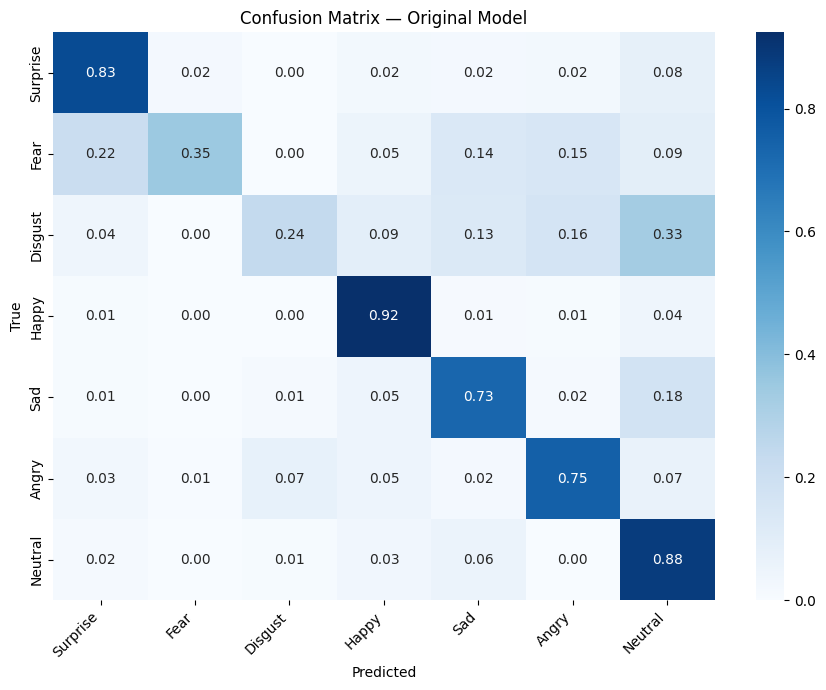


  Occluded Model
  Accuracy  : 80.96%
  Precision : 0.8028
  Recall    : 0.8096
  F1-Score  : 0.7993
              precision    recall  f1-score   support

    Surprise       0.79      0.81      0.80       329
        Fear       0.82      0.38      0.52        74
     Disgust       0.50      0.19      0.27       160
       Happy       0.91      0.94      0.92      1185
         Sad       0.80      0.75      0.77       478
       Angry       0.66      0.74      0.70       162
     Neutral       0.72      0.84      0.78       680

    accuracy                           0.81      3068
   macro avg       0.74      0.66      0.68      3068
weighted avg       0.80      0.81      0.80      3068



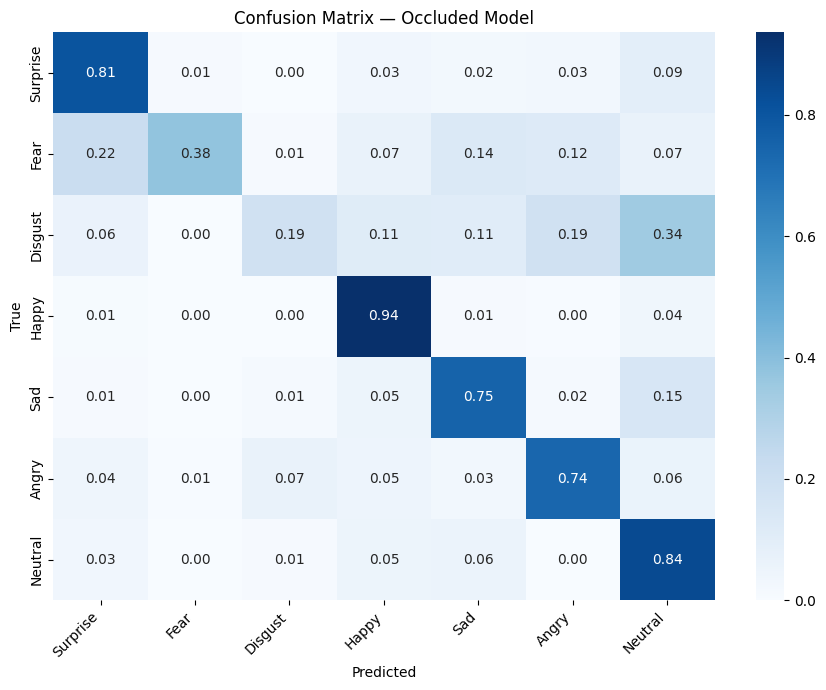

In [ ]:
# NOTE: Define helper functions to get predictions, calculate metrics, and plot confusion matrices.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns


def get_predictions(model, dataloader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())

            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


def print_metrics(preds, labels, model_name):

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")

    print(f"  Accuracy  : {accuracy_score(labels, preds) * 100:.2f}%")
    print(f"  Precision : {precision_score(labels, preds, average='weighted', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(labels, preds, average='weighted', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(labels, preds, average='weighted', zero_division=0):.4f}")

    print(classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0))


def plot_confusion_matrix(preds, labels, model_name):

    cm = confusion_matrix(labels, preds).astype("float")

    cm = cm / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


orig_preds, orig_labels = get_predictions(model_original, dataloaders["test"])

print_metrics(orig_preds, orig_labels, "Original Model")

plot_confusion_matrix(orig_preds, orig_labels, "Original Model")


occ_preds, occ_labels = get_predictions(model_occluded, dataloaders["test"])

print_metrics(occ_preds, occ_labels, "Occluded Model")

plot_confusion_matrix(occ_preds, occ_labels, "Occluded Model")


  Metric           Original   Occluded
  ----------------------------------------
  Accuracy           81.55%     80.96%
  Precision          0.8135     0.8028
  Recall             0.8155     0.8096
  F1-Score           0.8069     0.7993


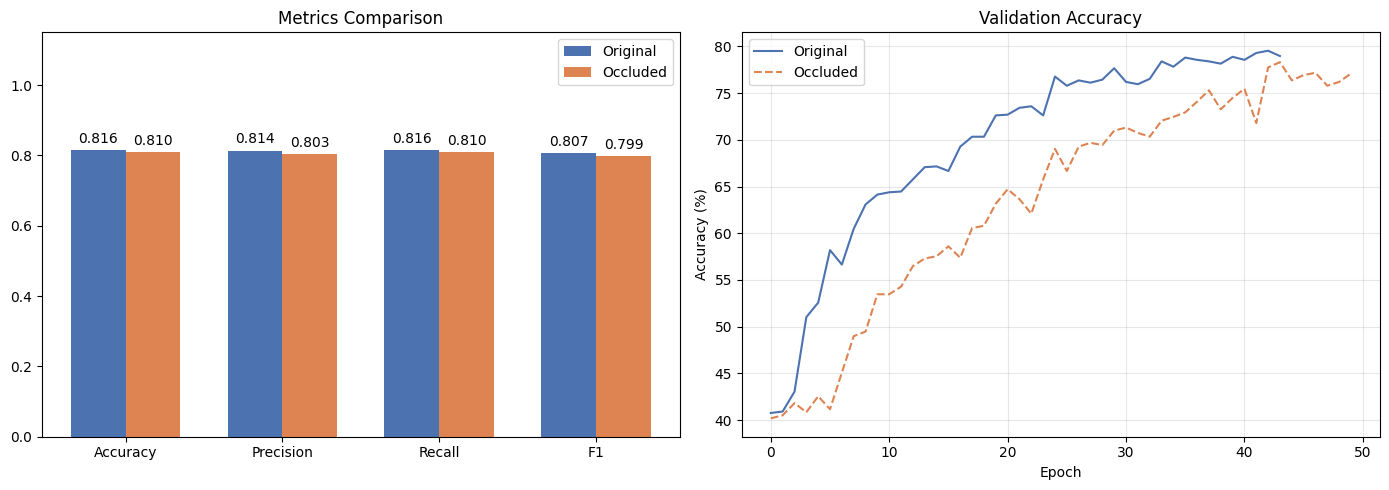

In [ ]:
# NOTE: Compare the original model and occluded model using common evaluation metrics.
orig_acc = accuracy_score(orig_labels, orig_preds)
occ_acc  = accuracy_score(occ_labels,  occ_preds)

orig_f1 = f1_score(orig_labels, orig_preds, average="weighted", zero_division=0)
occ_f1  = f1_score(occ_labels,  occ_preds,  average="weighted", zero_division=0)

orig_precision = precision_score(orig_labels, orig_preds, average="weighted", zero_division=0)
occ_precision  = precision_score(occ_labels,  occ_preds,  average="weighted", zero_division=0)

orig_recall = recall_score(orig_labels, orig_preds, average="weighted", zero_division=0)
occ_recall  = recall_score(occ_labels,  occ_preds,  average="weighted", zero_division=0)


print(f"{'='*52}")
print(f"  {'Metric':<14} {'Original':>10} {'Occluded':>10}")
print(f"  {'-'*40}")
print(f"  {'Accuracy':<14} {orig_acc*100:>9.2f}% {occ_acc*100:>9.2f}%")
print(f"  {'Precision':<14} {orig_precision:>10.4f} {occ_precision:>10.4f}")
print(f"  {'Recall':<14} {orig_recall:>10.4f} {occ_recall:>10.4f}")
print(f"  {'F1-Score':<14} {orig_f1:>10.4f} {occ_f1:>10.4f}")
print(f"{'='*52}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ["Accuracy", "Precision", "Recall", "F1"]
orig_vals = [orig_acc, orig_precision, orig_recall, orig_f1]
occ_vals  = [occ_acc,  occ_precision,  occ_recall,  occ_f1]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width / 2, orig_vals, width, label="Original", color="#4C72B0")
bars2 = axes[0].bar(x + width / 2, occ_vals,  width, label="Occluded", color="#DD8452")

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15)
axes[0].set_title("Metrics Comparison")
axes[0].legend()
axes[0].bar_label(bars1, fmt="%.3f", padding=3)
axes[0].bar_label(bars2, fmt="%.3f", padding=3)


axes[1].plot(val_accuracies_original, label="Original", color="#4C72B0")
axes[1].plot(val_accuracies_occluded, label="Occluded", color="#DD8452", linestyle="--")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


م

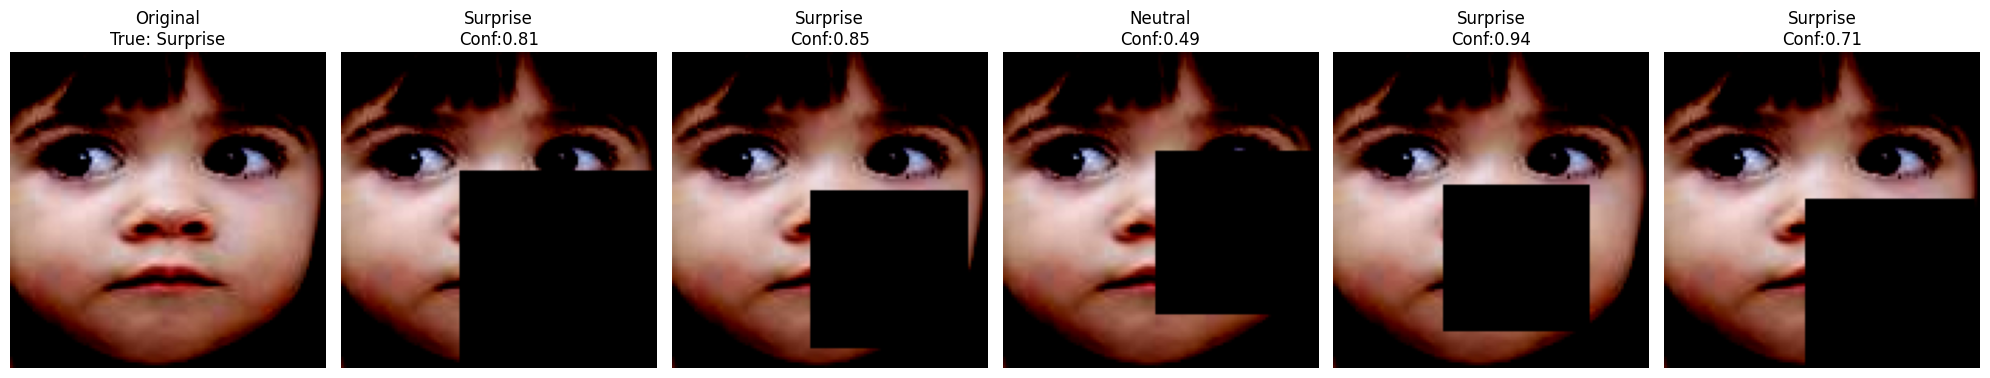

In [ ]:
# NOTE: Test stronger random occlusion on one image and compare model predictions visually.
import random
import matplotlib.pyplot as plt
import torch

emotion_classes = [
    'Surprise','Fear','Disgust',
    'Happy','Sad','Angry','Neutral'
]

# Stronger Random Occlusion
def random_occlusion(img, min_size=50, max_size=90):

    img = img.clone()

    _, h, w = img.shape

    # bigger block
    occ_size = random.randint(min_size, max_size)

    # focus more on center face area
    x = random.randint(w//4, w//2)
    y = random.randint(h//4, h//2)

    # avoid overflow
    x = min(x, w - occ_size)
    y = min(y, h - occ_size)

    # apply black square
    img[:, y:y+occ_size, x:x+occ_size] = 0

    return img

# Get one test image
images, labels = next(iter(dataloaders["test"]))

image = images[0]

label = labels[0].item()

# Plot
fig, axes = plt.subplots(1,6, figsize=(20,5))

# Original image
axes[0].imshow(
    image.permute(1,2,0).clamp(0,1)
)

axes[0].set_title(
    f"Original\nTrue: {emotion_classes[label]}"
)

axes[0].axis("off")

# Multiple occlusion tests
model_occluded.eval()

for i in range(5):

    occ_img = random_occlusion(image)

    input_tensor = occ_img.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model_occluded(input_tensor)

        probs = torch.softmax(output, dim=1)

        pred = torch.argmax(probs,1).item()

        confidence = probs[0][pred].item()

    axes[i+1].imshow(
        occ_img.permute(1,2,0).clamp(0,1)
    )

    axes[i+1].set_title(
        f"{emotion_classes[pred]}\nConf:{confidence:.2f}"
    )

    axes[i+1].axis("off")

plt.tight_layout()

plt.show()

# **COMPARISON**


MODEL COMPARISON
       Model  Accuracy  Precision  Recall  F1-Score
         CNN    0.8155     0.8135  0.8155    0.8069
Occluded CNN    0.8096     0.8028  0.8096    0.7993
    ResNet18    0.5310     0.5110  0.5310    0.5118


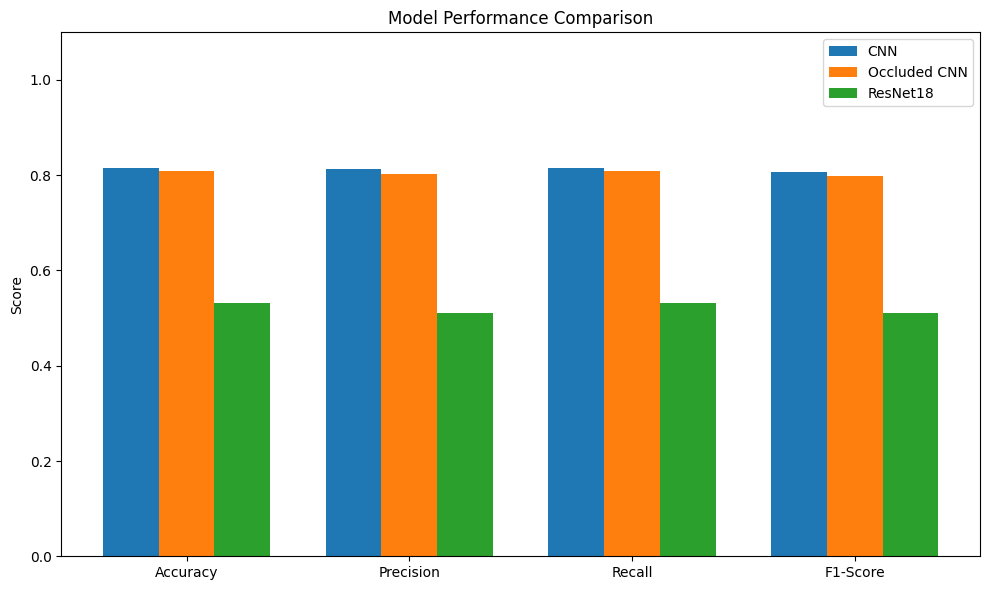

In [ ]:
# NOTE: Compare CNN, occluded CNN, and ResNet18 using metrics and visual plots.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# FUNCTION: GET PREDICTIONS
def get_predictions(model, dataloader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


# GET PREDICTIONS

cnn_preds, cnn_labels = get_predictions(
    model_original,
    dataloaders["test"]
)

occ_preds, occ_labels = get_predictions(
    model_occluded,
    dataloaders["test"]
)

resnet_preds, resnet_labels = get_predictions(
    resnet_model,
    dataloaders["test"]
)



# CALCULATE METRICS

results = []

models_dict = {
    "CNN": (cnn_preds, cnn_labels),
    "Occluded CNN": (occ_preds, occ_labels),
    "ResNet18": (resnet_preds, resnet_labels)
}

for model_name, (preds, labels) in models_dict.items():

    accuracy = accuracy_score(labels, preds)

    precision = precision_score(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])



# RESULTS TABLE


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print("\nMODEL COMPARISON")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format="%.4f"
    )
)


# BAR CHART


metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

cnn_vals = results_df.iloc[0, 1:].values
occ_vals = results_df.iloc[1, 1:].values
resnet_vals = results_df.iloc[2, 1:].values

ax.bar(
    x - width,
    cnn_vals,
    width,
    label="CNN"
)

ax.bar(
    x,
    occ_vals,
    width,
    label="Occluded CNN"
)

ax.bar(
    x + width,
    resnet_vals,
    width,
    label="ResNet18"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(0, 1.1)

ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# NOTE: Save the trained occluded model to a file.
# Save occluded model
torch.save(model_occluded.state_dict(), "emotion_model_occluded.pth")
print("Occluded model saved as emotion_model_occluded.pth")

Occluded model saved as emotion_model_occluded.pth


In [ ]:
# NOTE: Build a simple Gradio app to predict emotion from an uploaded image.
import gradio as gr
from PIL import Image
import torch
from torchvision import transforms

emotion_classes = CLASS_NAMES

transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

def predict_emotion(image):

    img_tensor = transform(image).unsqueeze(0).to(device)

    model_original.eval()
    model_occluded.eval()

    with torch.no_grad():

        output_original = model_original(img_tensor)
        output_occluded = model_occluded(img_tensor)

        probs_original = torch.softmax(output_original, dim=1)
        probs_occluded = torch.softmax(output_occluded, dim=1)

        conf_original = torch.max(probs_original).item()
        conf_occluded = torch.max(probs_occluded).item()

        if conf_occluded > conf_original:
            probs = probs_occluded
            model_used = "Occluded Model"
        else:
            probs = probs_original
            model_used = "Original Model"

        result = {}

        for i, emotion in enumerate(emotion_classes):
            result[emotion] = float(probs[0][i])

        return result, model_used

demo = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Label(num_top_classes=3),
        gr.Textbox(label="Model Used")
    ],
    title="Emotion Recognition System",
    description="Upload any face image and the system will automatically predict the top 3 emotions."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4176daa65dd21c46e1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
